# Продуктовий аналіз продажів Superstore

Мета аналізу — зрозуміти динаміку продажів і прибутку, визначити сезонні періоди та аномалії, а також порівняти групи клієнтів. Джерело даних: локальний файл `Sample - Superstore.xls`, аркуш `Orders`.

Одиниця спостереження у таблиці — товарна позиція в замовленні. Тому продажі та прибуток підсумовуємо, а замовлення й клієнтів рахуємо за унікальними ідентифікаторами. Такий підхід не змішує кількість рядків із реальною кількістю замовлень або клієнтів.

## Завдання 1. Підготувати робочий файл і дані

Завантажуємо локальну копію робочого файлу, перевіряємо структуру та якість даних і створюємо єдину підготовлену таблицю `prepared_df` для всіх наступних розрахунків.

In [1]:
from pathlib import Path

import pandas as pd

DATA_PATH = Path("Sample - Superstore.xls")
SHEET_NAME = "Orders"

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Не знайдено файл даних: {DATA_PATH}")

raw_df = pd.read_excel(DATA_PATH, sheet_name=SHEET_NAME, engine="xlrd")
raw_df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2020-103800,2020-01-03,2020-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2020-112326,2020-01-04,2020-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2020-112326,2020-01-04,2020-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2020-112326,2020-01-04,2020-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2020-141817,2020-01-05,2020-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


### Первинна перевірка

Перевіряємо розмір таблиці, склад полів, типи, пропуски й повні дублікати. Це фіксує вихідний стан даних перед підготовкою.

In [2]:
print(f"Розмір таблиці: {raw_df.shape[0]} рядків × {raw_df.shape[1]} колонок")
print("\nНазви колонок:")
print(raw_df.columns.tolist())

print("\nТипи даних:")
display(raw_df.dtypes.rename("Тип даних").to_frame())

print("Кількість пропусків за колонками:")
display(raw_df.isna().sum().rename("Пропуски").to_frame())

print(f"Кількість повних дублікатів: {raw_df.duplicated().sum()}")

Розмір таблиці: 10194 рядків × 21 колонок

Назви колонок:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City', 'State/Province', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

Типи даних:


,Тип даних
Row ID,int64
Order ID,object
Order Date,datetime64[ns]
Ship Date,datetime64[ns]
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country/Region,object
City,object


Кількість пропусків за колонками:


,Пропуски
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country/Region,0
City,0


Кількість повних дублікатів: 0


### Підготовка даних

Дати замовлення й відправлення перетворюємо на `datetime`, а ключові кількісні показники — на числові значення. Перетворення виконуються з `errors="raise"`, щоб не приховувати некоректні значення. Рядки не вилучаємо: подальші завдання працюватимуть з повним набором замовлень, а специфічні правила обробки пропусків або дублікатів будуть визначені лише за потреби аналізу.

In [3]:
date_columns = ["Order Date", "Ship Date"]
numeric_columns = ["Row ID", "Sales", "Quantity", "Discount", "Profit"]

prepared_df = raw_df.copy()

for column in date_columns:
    prepared_df[column] = pd.to_datetime(prepared_df[column], errors="raise")

for column in numeric_columns:
    prepared_df[column] = pd.to_numeric(prepared_df[column], errors="raise")

prepared_df[date_columns + numeric_columns].dtypes.rename("Тип даних після підготовки").to_frame()

,Тип даних після підготовки
Order Date,datetime64[ns]
Ship Date,datetime64[ns]
Row ID,int64
Sales,float64
Quantity,int64
Discount,float64
Profit,float64


In [4]:
assert prepared_df.shape == raw_df.shape, "Підготовка не має змінювати кількість рядків або колонок"
assert prepared_df[date_columns].notna().all().all(), "Поля дат містять пропуски після перетворення"

print("Підготовлена таблиця готова до наступних розрахунків.")
print(f"Період замовлень: {prepared_df['Order Date'].min():%Y-%m-%d} — {prepared_df['Order Date'].max():%Y-%m-%d}")
display(prepared_df.head())

Підготовлена таблиця готова до наступних розрахунків.
Період замовлень: 2020-01-03 — 2023-12-30


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2020-103800,2020-01-03,2020-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2020-112326,2020-01-04,2020-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2020-112326,2020-01-04,2020-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2020-112326,2020-01-04,2020-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2020-141817,2020-01-05,2020-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


## Завдання 2. Сезонність, аномалії та групи клієнтів

У цьому блоці відповідаємо на три продуктові питання: коли попит і прибуток системно зростають або знижуються, які місяці нетипові та як згрупувати клієнтів для коректного порівняння. Для часового ряду використовуємо місячну гранулярність (`MS`), яка дає 48 календарних місяців у 2020–2023 роках. Окрім продажів і прибутку, рахуємо унікальні замовлення та клієнтів, щоб відокремити зміну грошового результату від зміни активності.

In [5]:
monthly_metrics = (
    prepared_df.set_index("Order Date")
    .resample("MS")
    .agg(
        sales=("Sales", "sum"),
        profit=("Profit", "sum"),
        order_count=("Order ID", "nunique"),
        customer_count=("Customer ID", "nunique"),
    )
)
monthly_metrics.index.name = "month"
monthly_metrics["year"] = monthly_metrics.index.year
monthly_metrics["calendar_month"] = monthly_metrics.index.month

assert len(monthly_metrics) == monthly_metrics.index.nunique()
assert monthly_metrics[["sales", "profit"]].notna().all().all()

display(monthly_metrics.round(2))

,sales,profit,order_count,customer_count,year,calendar_month
month,,,,,,
2020-01-01,14518.06,2539.39,33,33,2020,1
2020-02-01,4519.89,862.31,28,27,2020,2
2020-03-01,56933.91,693.45,72,70,2020,3
2020-04-01,28295.34,3488.84,66,64,2020,4
2020-05-01,26319.77,3196.39,72,68,2020,5
2020-06-01,34669.48,4999.76,67,64,2020,6
2020-07-01,33946.39,-841.48,65,65,2020,7
2020-08-01,28918.34,5765.22,75,73,2020,8
2020-09-01,82670.43,8593.63,134,121,2020,9


### Відокремлення тренду від сезонності

Зростання бізнесу між роками може помилково виглядати як сезонність. Тому для кожного року базою є його середній місячний рівень продажів і прибутку. Сезонний індекс дорівнює місячному значенню, поділеному на цю базу; значення понад 1 означає рівень вище типового для відповідного року. Порівняння середніх індексів за номером календарного місяця показує повторюваний патерн незалежно від масштабу окремого року.

In [6]:
yearly_baseline = monthly_metrics.groupby("year")[["sales", "profit"]].transform("mean")
monthly_metrics["sales_seasonal_index"] = monthly_metrics["sales"] / yearly_baseline["sales"]
monthly_metrics["profit_seasonal_index"] = monthly_metrics["profit"] / yearly_baseline["profit"]

seasonality_by_month = (
    monthly_metrics.groupby("calendar_month")
    .agg(
        mean_sales=("sales", "mean"),
        mean_profit=("profit", "mean"),
        sales_seasonal_index=("sales_seasonal_index", "mean"),
        profit_seasonal_index=("profit_seasonal_index", "mean"),
    )
)
seasonality_by_month.index.name = "calendar_month"

sales_peak = seasonality_by_month["sales_seasonal_index"].idxmax()
sales_low = seasonality_by_month["sales_seasonal_index"].idxmin()
profit_peak = seasonality_by_month["profit_seasonal_index"].idxmax()
profit_low = seasonality_by_month["profit_seasonal_index"].idxmin()

display(seasonality_by_month.round(3))
print(f"Продажі: сезонний пік — місяць {sales_peak}, спад — місяць {sales_low}.")
print(f"Прибуток: сезонний пік — місяць {profit_peak}, спад — місяць {profit_low}.")

,mean_sales,mean_profit,sales_seasonal_index,profit_seasonal_index
calendar_month,,,,
1,24017.379,2374.313,0.475,0.325
2,14937.813,2573.653,0.297,0.418
3,52668.022,7336.260,1.103,1.125
4,34524.687,2906.381,0.726,0.544
5,39691.258,5712.508,0.812,0.924
6,38364.999,5377.052,0.781,0.888
7,37250.428,3503.387,0.771,0.495
8,40455.479,5735.606,0.824,0.975
9,77220.917,9308.640,1.626,1.582


Продажі: сезонний пік — місяць 11, спад — місяць 2.
Прибуток: сезонний пік — місяць 12, спад — місяць 1.


### Аномальні місяці

Аномалії шукаємо на рівні місячних сум, а не окремих рядків замовлень: так правило відповідає часовому ряду. Для `sales` і `profit` окремо застосовуємо IQR: нижня межа `Q1 − 1.5 × IQR`, верхня — `Q3 + 1.5 × IQR`. Місяць вважаємо аномальним, якщо хоча б один показник виходить за власні межі. Це статистичне позначення, а не доказ причини зміни.

In [7]:
def iqr_limits(series: pd.Series) -> tuple[float, float]:
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

anomaly_limits = {metric: iqr_limits(monthly_metrics[metric]) for metric in ["sales", "profit"]}
for metric, (lower_limit, upper_limit) in anomaly_limits.items():
    monthly_metrics[f"{metric}_is_anomaly"] = (
        (monthly_metrics[metric] < lower_limit) | (monthly_metrics[metric] > upper_limit)
    )

monthly_metrics["is_anomaly"] = monthly_metrics[["sales_is_anomaly", "profit_is_anomaly"]].any(axis=1)
anomaly_periods = monthly_metrics.loc[
    monthly_metrics["is_anomaly"],
    ["sales", "profit", "order_count", "customer_count", "sales_is_anomaly", "profit_is_anomaly"],
].copy()

limits_table = pd.DataFrame(anomaly_limits, index=["lower_limit", "upper_limit"]).T
display(limits_table.round(2))
display(anomaly_periods.round(2))
print(f"Кількість аномальних місяців: {len(anomaly_periods)}.")

,lower_limit,upper_limit
sales,-24921.56,121308.71
profit,-5409.37,17402.84


,sales,profit,order_count,customer_count,sales_is_anomaly,profit_is_anomaly
month,,,,,,
2022-12-01,97502.28,17926.3,185,163,False,True


Кількість аномальних місяців: 1.


### Когорти клієнтів за першою покупкою

У даних є стабільний `Customer ID`, дата замовлення та поле `Segment`; пропусків у цих полях не допускаємо. Для відтворюваного групування використовуємо когорту першої покупки: усі замовлення клієнта належать кварталу, у якому зафіксовано його найранішу дату замовлення. Це правило не пояснює мотиви клієнтів, але однозначно визначає належність до групи.

In [8]:
cohort_required_columns = ["Customer ID", "Order Date", "Segment"]
missing_cohort_columns = set(cohort_required_columns).difference(prepared_df.columns)
if missing_cohort_columns:
    raise KeyError(f"Відсутні поля для когорт: {sorted(missing_cohort_columns)}")
if prepared_df[cohort_required_columns].isna().any().any():
    raise ValueError("Поля для когорт містять пропуски")

first_purchase = prepared_df.groupby("Customer ID")["Order Date"].min().rename("first_purchase_date")
prepared_df = prepared_df.join(first_purchase, on="Customer ID")
prepared_df["first_purchase_cohort"] = prepared_df["first_purchase_date"].dt.to_period("Q").astype(str)

cohort_summary = (
    prepared_df.groupby("first_purchase_cohort")
    .agg(
        customers=("Customer ID", "nunique"),
        orders=("Order ID", "nunique"),
        sales=("Sales", "sum"),
        profit=("Profit", "sum"),
    )
    .sort_index()
)

assert cohort_summary["customers"].sum() == prepared_df["Customer ID"].nunique()
display(cohort_summary.round(2))
display(prepared_df[["Customer ID", "Order Date", "first_purchase_date", "first_purchase_cohort", "Segment"]].head())

,customers,orders,sales,profit
first_purchase_cohort,,,,
2020Q1,123,854,421740.29,52599.07
2020Q2,161,1145,514052.46,51084.80
2020Q3,164,1133,490733.18,55663.83
2020Q4,157,1018,456231.43,70151.70
2021Q1,32,179,89201.01,15760.12
2021Q2,34,194,90076.29,4974.62
2021Q3,34,198,80701.58,16503.97
2021Q4,31,134,59330.00,5211.30
2022Q1,15,81,33655.90,4227.67


,Customer ID,Order Date,first_purchase_date,first_purchase_cohort,Segment
0,DP-13000,2020-01-03,2020-01-03,2020Q1,Consumer
1,PO-19195,2020-01-04,2020-01-04,2020Q1,Home Office
2,PO-19195,2020-01-04,2020-01-04,2020Q1,Home Office
3,PO-19195,2020-01-04,2020-01-04,2020Q1,Home Office
4,MB-18085,2020-01-05,2020-01-05,2020Q1,Consumer


### Обмеження інтерпретації

Дані показують спостережувану динаміку, але не містять контексту промоакцій, змін цін, асортименту чи зовнішніх подій, тому причинні пояснення не робимо. `first_purchase_cohort` означає квартал першої покупки, яку видно саме в цьому датасеті. Оскільки історія починається у 2020 році, для ранніх клієнтів це не обов'язково реальна дата залучення. Нові когорти також мають коротший період спостереження, тому їхні накопичені продажі не можна напряму порівнювати зі старшими когортами як показник цінності.

## Завдання 3. Візуалізувати результати

Кожна візуалізація відповідає окремому продуктовому питанню: як змінюються ключові метрики в часі, коли проявляється сезонність, які категорії та клієнтські сегменти формують результат, де розташовані крайні значення і як поводяться когорти. Графіки будуються з таблиць, підготовлених у Завданні 2. Грошові показники подано в USD відповідно до вихідного файлу.

In [9]:
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
COLORS = {"sales": "#1f77b4", "profit": "#2ca02c", "anomaly": "#d62728"}

### Динаміка продажів і прибутку

Два окремі масштаби по осі Y не змішують продажі з прибутком. Найбільші місячні продажі зафіксовано в листопаді 2023 року, а найбільший місячний прибуток — у грудні 2022 року; найменший місячний прибуток був від'ємним у січні 2021 року.

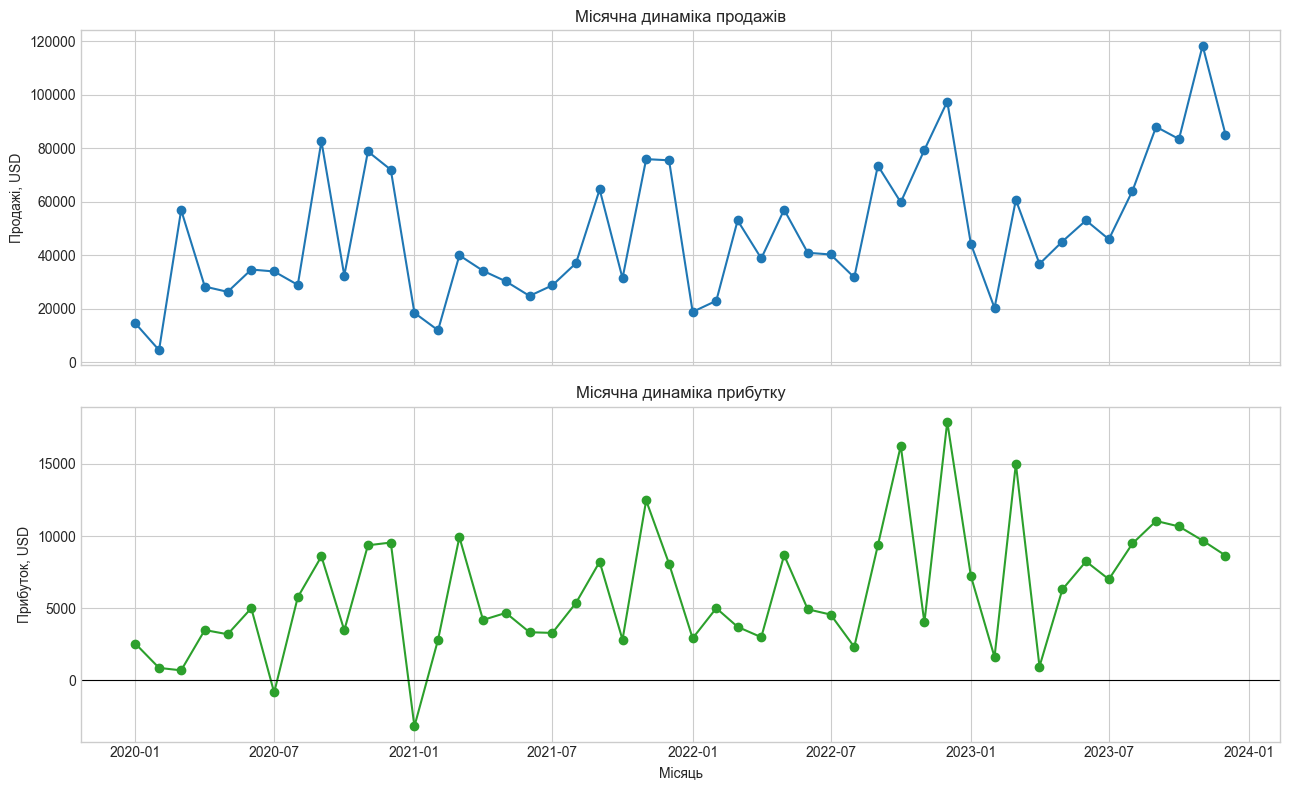

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

axes[0].plot(monthly_metrics.index, monthly_metrics["sales"], color=COLORS["sales"], marker="o")
axes[0].set_title("Місячна динаміка продажів")
axes[0].set_ylabel("Продажі, USD")

axes[1].plot(monthly_metrics.index, monthly_metrics["profit"], color=COLORS["profit"], marker="o")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("Місячна динаміка прибутку")
axes[1].set_xlabel("Місяць")
axes[1].set_ylabel("Прибуток, USD")

fig.tight_layout()
plt.show()

### Сезонність після нормалізації на річний рівень

Лінія на рівні 1 показує середній місячний рівень відповідного року. За сезонним індексом продажів найвищий середній рівень має листопад, а найнижчий — лютий. Для прибутку пік припадає на грудень, а спад — на січень.

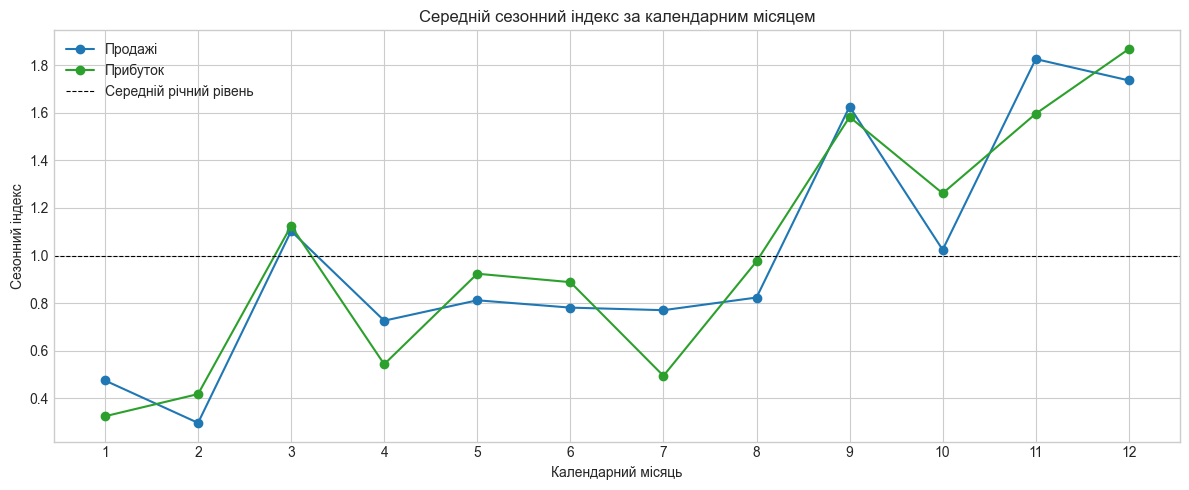

In [11]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(seasonality_by_month.index, seasonality_by_month["sales_seasonal_index"], marker="o", label="Продажі", color=COLORS["sales"])
ax.plot(seasonality_by_month.index, seasonality_by_month["profit_seasonal_index"], marker="o", label="Прибуток", color=COLORS["profit"])
ax.axhline(1, color="black", linestyle="--", linewidth=0.8, label="Середній річний рівень")
ax.set_title("Середній сезонний індекс за календарним місяцем")
ax.set_xlabel("Календарний місяць")
ax.set_ylabel("Сезонний індекс")
ax.set_xticks(range(1, 13))
ax.legend()
fig.tight_layout()
plt.show()

### Порівняння категорій і сегментів

Technology має найбільші сукупні продажі й прибуток серед категорій. У сегментах найбільші суми продажів і прибутку має Consumer. Це опис сум за весь період, а не порівняння маржинальності чи причин переваги.

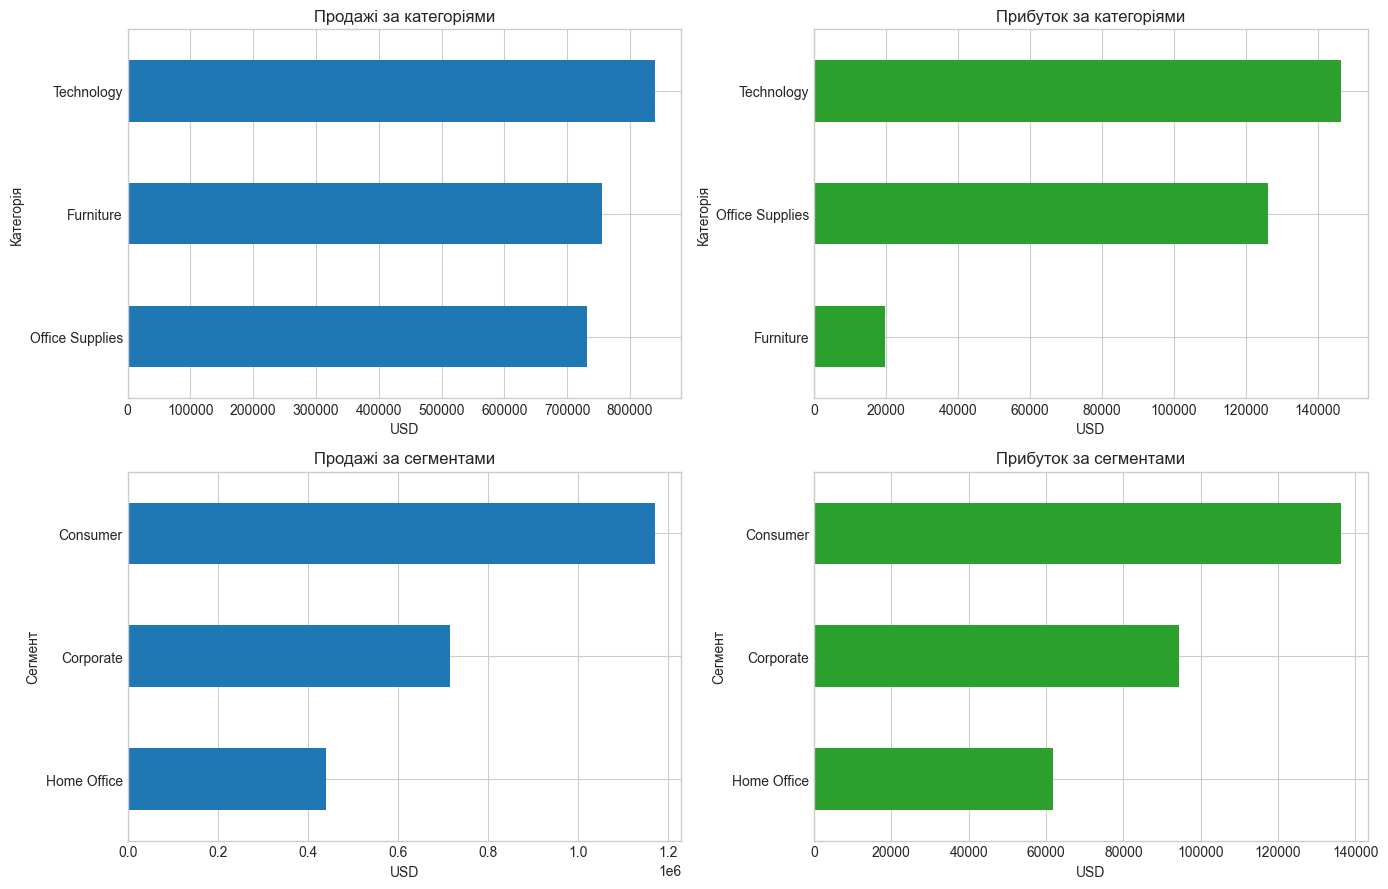

In [12]:
category_summary = prepared_df.groupby("Category")[["Sales", "Profit"]].sum().sort_values("Sales", ascending=False)
segment_summary = prepared_df.groupby("Segment")[["Sales", "Profit"]].sum().sort_values("Sales", ascending=False)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for axis, (metric, title) in zip(axes[0], [("Sales", "Продажі за категоріями"), ("Profit", "Прибуток за категоріями")]):
    category_summary[metric].sort_values().plot.barh(ax=axis, color=COLORS["sales"] if metric == "Sales" else COLORS["profit"])
    axis.set_title(title)
    axis.set_xlabel("USD")
    axis.set_ylabel("Категорія")

for axis, (metric, title) in zip(axes[1], [("Sales", "Продажі за сегментами"), ("Profit", "Прибуток за сегментами")]):
    segment_summary[metric].sort_values().plot.barh(ax=axis, color=COLORS["sales"] if metric == "Sales" else COLORS["profit"])
    axis.set_title(title)
    axis.set_xlabel("USD")
    axis.set_ylabel("Сегмент")

fig.tight_layout()
plt.show()

### Розподіли продажів і прибутку

Гістограми та boxplot показують форму розподілів і вплив крайніх значень. Для додатних продажів застосовано логарифмічну шкалу. Прибуток містить від'ємні й нульові значення, тому для нього використано симетричну логарифмічну шкалу `symlog`, яка зберігає знак. За таких розподілів для продуктових рішень потрібно аналізувати не лише середнє, а й медіану, квартилі та розмір вибірки; ці показники розраховано в Завданні 4.

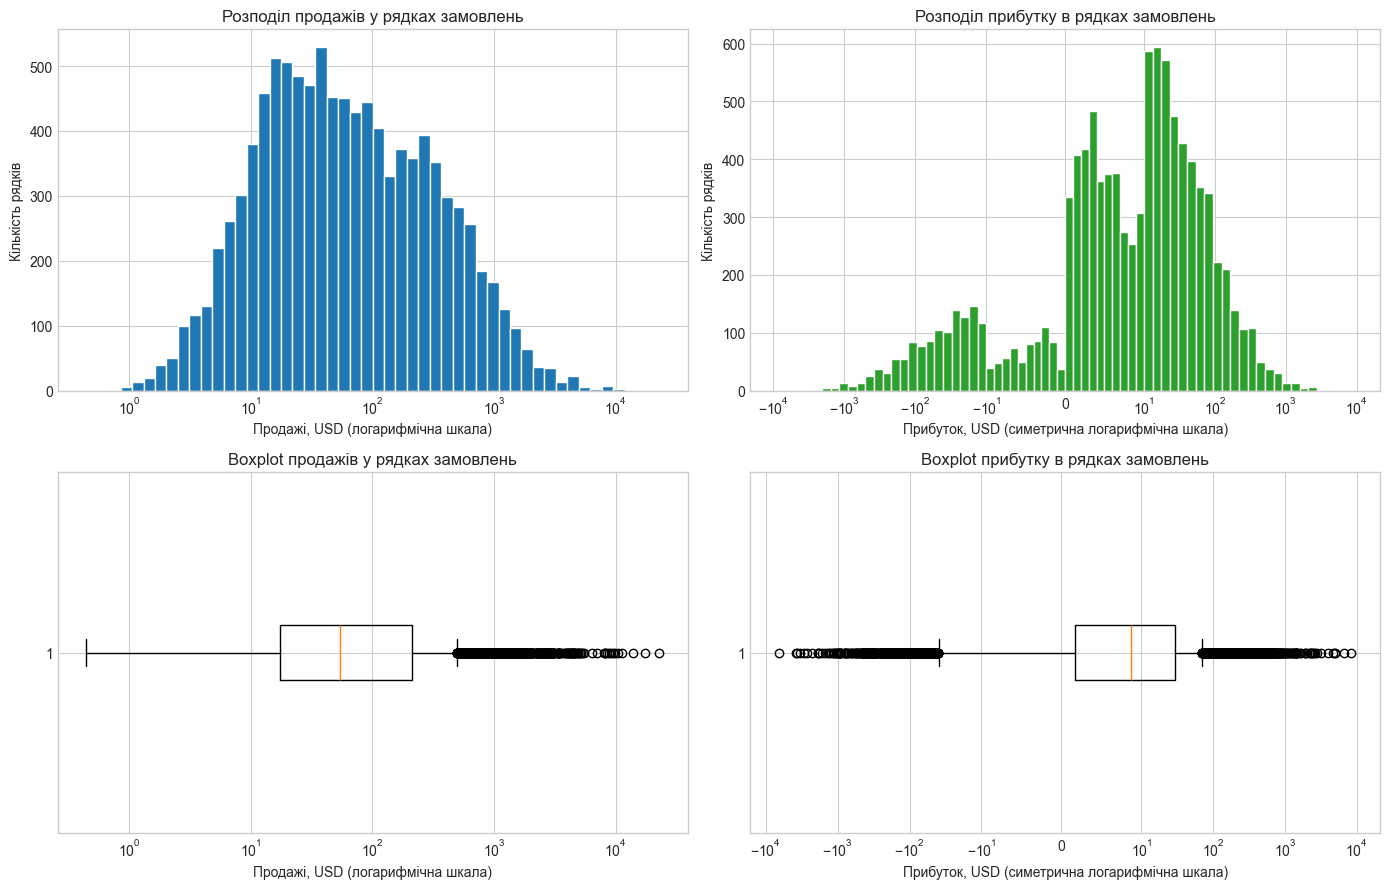

In [13]:
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

sales_values = prepared_df["Sales"]
sales_bins = np.geomspace(sales_values.min(), sales_values.max(), 51)
axes[0, 0].hist(sales_values, bins=sales_bins, color=COLORS["sales"], edgecolor="white")
axes[0, 0].set_title("Розподіл продажів у рядках замовлень")
axes[0, 0].set_xlabel("Продажі, USD (логарифмічна шкала)")
axes[0, 0].set_ylabel("Кількість рядків")
axes[0, 0].set_xscale("log")

profit_values = prepared_df["Profit"]
profit_linear_threshold = 10
profit_max = max(abs(profit_values.min()), abs(profit_values.max()))
profit_bins = np.unique(np.concatenate([
    -np.geomspace(profit_max, profit_linear_threshold, 25),
    np.linspace(-profit_linear_threshold, profit_linear_threshold, 21),
    np.geomspace(profit_linear_threshold, profit_max, 25),
]))
axes[0, 1].hist(profit_values, bins=profit_bins, color=COLORS["profit"], edgecolor="white")
axes[0, 1].set_title("Розподіл прибутку в рядках замовлень")
axes[0, 1].set_xlabel("Прибуток, USD (симетрична логарифмічна шкала)")
axes[0, 1].set_ylabel("Кількість рядків")
axes[0, 1].set_xscale("symlog", linthresh=profit_linear_threshold)

axes[1, 0].boxplot(sales_values, vert=False)
axes[1, 0].set_title("Boxplot продажів у рядках замовлень")
axes[1, 0].set_xlabel("Продажі, USD (логарифмічна шкала)")
axes[1, 0].set_xscale("log")

axes[1, 1].boxplot(profit_values, vert=False)
axes[1, 1].set_title("Boxplot прибутку в рядках замовлень")
axes[1, 1].set_xlabel("Прибуток, USD (симетрична логарифмічна шкала)")
axes[1, 1].set_xscale("symlog", linthresh=profit_linear_threshold)

fig.tight_layout()
plt.show()

### Аномальні місяці за правилом IQR

Червоними точками позначено періоди, які в Завданні 2 відібрано правилом IQR. У поточних даних один аномальний місяць має прибуток вище верхньої межі IQR: грудень 2022 року. Графік показує факт відхилення, але не встановлює його причину.

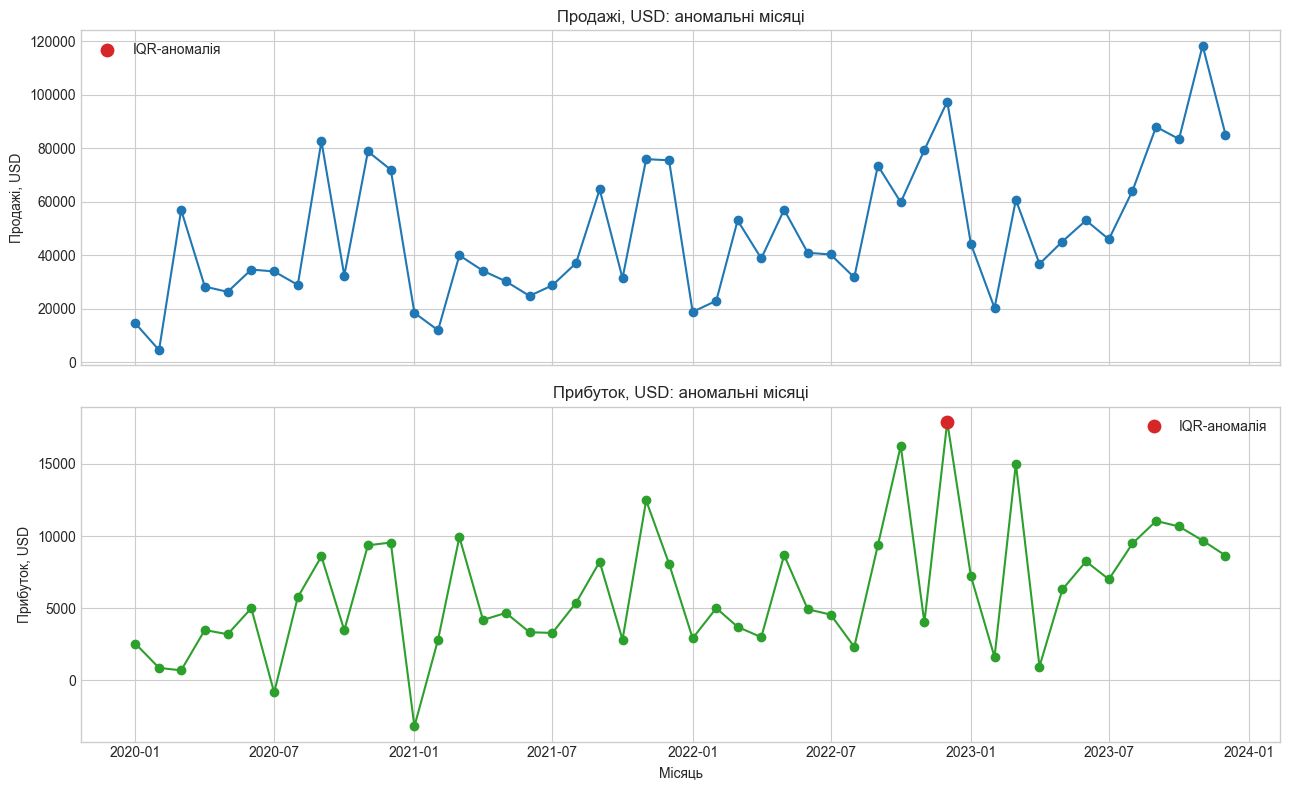

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
for axis, metric, label, color in [
    (axes[0], "sales", "Продажі, USD", COLORS["sales"]),
    (axes[1], "profit", "Прибуток, USD", COLORS["profit"]),
]:
    axis.plot(monthly_metrics.index, monthly_metrics[metric], color=color, marker="o")
    flagged = monthly_metrics[monthly_metrics[f"{metric}_is_anomaly"]]
    axis.scatter(flagged.index, flagged[metric], color=COLORS["anomaly"], s=80, label="IQR-аномалія", zorder=3)
    axis.set_title(f"{label}: аномальні місяці")
    axis.set_ylabel(label)
    axis.legend()

axes[1].set_xlabel("Місяць")
fig.tight_layout()
plt.show()

### Продажі когорт за роками замовлень

Теплова карта показує суму продажів у USD для поєднання когорти першої покупки та року замовлення. Найбільшу сукупну суму за весь доступний період має когорта 2020Q2. Нові когорти мають коротший період спостереження, тому нижчі суми не слід тлумачити як нижчу цінність клієнтів без нормалізації за тривалістю.

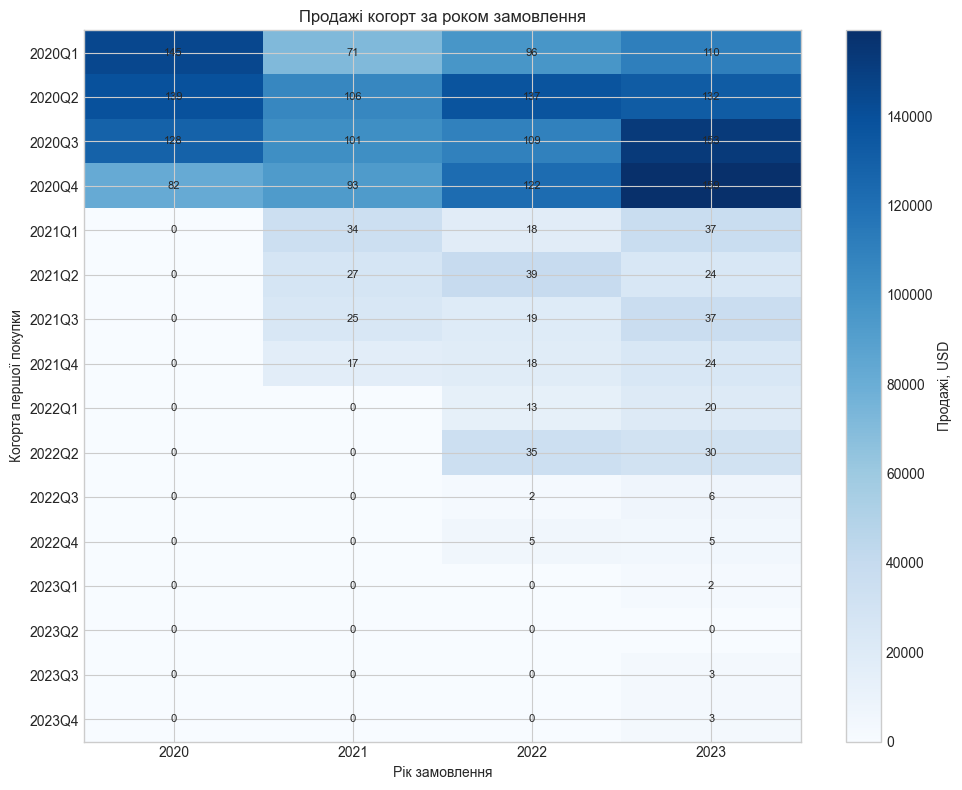

In [15]:
cohort_sales_by_year = (
    prepared_df.assign(order_year=prepared_df["Order Date"].dt.year)
    .pivot_table(
        index="first_purchase_cohort",
        columns="order_year",
        values="Sales",
        aggfunc="sum",
        fill_value=0,
    )
    .sort_index()
)

fig, ax = plt.subplots(figsize=(10, 8))
image = ax.imshow(cohort_sales_by_year.values, cmap="Blues", aspect="auto")
ax.set_title("Продажі когорт за роком замовлення")
ax.set_xlabel("Рік замовлення")
ax.set_ylabel("Когорта першої покупки")
ax.set_xticks(range(len(cohort_sales_by_year.columns)), cohort_sales_by_year.columns)
ax.set_yticks(range(len(cohort_sales_by_year.index)), cohort_sales_by_year.index)

for row_index, cohort in enumerate(cohort_sales_by_year.index):
    for column_index, year in enumerate(cohort_sales_by_year.columns):
        value = cohort_sales_by_year.loc[cohort, year]
        ax.text(column_index, row_index, f"{value / 1000:.0f}", ha="center", va="center", fontsize=8)

colorbar = fig.colorbar(image, ax=ax)
colorbar.set_label("Продажі, USD")
fig.tight_layout()
plt.show()

Часові ряди показують динаміку, сезонний індекс — повторюваний календарний патерн, стовпчикові діаграми — внесок категорій і сегментів, розподіли та IQR-графік — крайні значення, а теплова карта — накопичені продажі когорт у часі. Разом вони дають контекст для описової статистики в наступному завданні.

## Завдання 4. Розрахувати описову статистику

Описову статистику обчислюємо з `prepared_df`, тобто з тієї самої підготовленої таблиці, яку використано в попередніх завданнях. Ключові числові метрики: продажі й прибуток у USD, кількість одиниць та знижка як частка від ціни.

In [16]:
statistic_metrics = ["Sales", "Quantity", "Discount", "Profit"]
statistic_labels = {
    "Sales": "Продажі, USD",
    "Quantity": "Кількість, од.",
    "Discount": "Знижка, частка",
    "Profit": "Прибуток, USD",
}

def descriptive_statistics(frame: pd.DataFrame, metrics: list[str]) -> pd.DataFrame:
    return pd.DataFrame(
        {
            "Кількість валідних значень": frame[metrics].count(),
            "Середнє": frame[metrics].mean(),
            "Медіана": frame[metrics].median(),
            "Стандартне відхилення": frame[metrics].std(),
            "Мінімум": frame[metrics].min(),
            "Q1 (25%)": frame[metrics].quantile(0.25),
            "Q3 (75%)": frame[metrics].quantile(0.75),
            "Максимум": frame[metrics].max(),
        }
    )

overall_statistics = descriptive_statistics(prepared_df, statistic_metrics)
overall_statistics.index = overall_statistics.index.map(statistic_labels)
overall_statistics.index.name = "Метрика"

assert overall_statistics["Кількість валідних значень"].eq(len(prepared_df)).all()
display(overall_statistics.round(2))

,Кількість валідних значень,Середнє,Медіана,Стандартне відхилення,Мінімум,Q1 (25%),Q3 (75%),Максимум
Метрика,,,,,,,,
"Продажі, USD",10194,228.23,53.91,619.91,0.44,17.22,209.5,22638.48
"Кількість, од.",10194,3.79,3.00,2.23,1.00,2.00,5.0,14.00
"Знижка, частка",10194,0.16,0.20,0.21,0.00,0.00,0.2,0.80
"Прибуток, USD",10194,28.67,8.69,232.47,-6599.98,1.76,29.3,8399.98


### Статистика за когортами першої покупки

Групи — це когорти `first_purchase_cohort`, визначені в Завданні 2. Для кожної метрики подано окрему таблицю: такий формат не приховує квартилі й водночас дозволяє порівнювати когорти. Когорти з малою кількістю рядків або коротким періодом спостереження слід інтерпретувати обережно.

In [17]:
def cohort_descriptive_statistics(metric: str) -> pd.DataFrame:
    return (
        prepared_df.groupby("first_purchase_cohort")[metric]
        .agg(
            **{
                "Кількість валідних значень": "count",
                "Середнє": "mean",
                "Медіана": "median",
                "Стандартне відхилення": "std",
                "Мінімум": "min",
                "Q1 (25%)": lambda values: values.quantile(0.25),
                "Q3 (75%)": lambda values: values.quantile(0.75),
                "Максимум": "max",
            }
        )
        .sort_index()
    )

cohort_statistics = {metric: cohort_descriptive_statistics(metric) for metric in statistic_metrics}

for metric, table in cohort_statistics.items():
    table.index.name = "Когорта першої покупки"
    print(f"{statistic_labels[metric]} за когортами")
    display(table.round(2))

cohort_comparison = pd.DataFrame(
    {
        "Кількість рядків": prepared_df.groupby("first_purchase_cohort").size(),
        "Середні продажі, USD": prepared_df.groupby("first_purchase_cohort")["Sales"].mean(),
        "Медіана продажів, USD": prepared_df.groupby("first_purchase_cohort")["Sales"].median(),
        "Середній прибуток, USD": prepared_df.groupby("first_purchase_cohort")["Profit"].mean(),
        "Медіана прибутку, USD": prepared_df.groupby("first_purchase_cohort")["Profit"].median(),
    }
).sort_index()
cohort_comparison.index.name = "Когорта першої покупки"
display(cohort_comparison.round(2))

Продажі, USD за когортами


,Кількість валідних значень,Середнє,Медіана,Стандартне відхилення,Мінімум,Q1 (25%),Q3 (75%),Максимум
Когорта першої покупки,,,,,,,,
2020Q1,1723,244.77,51.47,801.16,0.85,17.23,209.50,22638.48
2020Q2,2302,223.31,58.22,516.15,0.56,17.94,223.83,9099.93
2020Q3,2239,219.18,51.17,553.26,0.88,16.97,196.74,11199.97
2020Q4,2001,228.00,50.96,653.95,0.44,15.99,199.98,17499.95
2021Q1,372,239.79,61.08,530.17,1.68,18.28,237.66,6354.95
2021Q2,377,238.93,62.50,461.73,0.99,18.50,227.96,4476.80
2021Q3,400,201.75,67.86,394.72,1.89,20.73,209.68,4355.17
2021Q4,257,230.86,52.56,497.80,1.41,14.98,196.78,4416.17
2022Q1,153,219.97,61.12,485.53,3.30,18.19,210.58,3999.95


Кількість, од. за когортами


,Кількість валідних значень,Середнє,Медіана,Стандартне відхилення,Мінімум,Q1 (25%),Q3 (75%),Максимум
Когорта першої покупки,,,,,,,,
2020Q1,1723,3.82,3.0,2.26,1,2.00,5.00,14
2020Q2,2302,3.86,3.0,2.25,1,2.00,5.00,14
2020Q3,2239,3.71,3.0,2.20,1,2.00,5.00,14
2020Q4,2001,3.80,3.0,2.16,1,2.00,5.00,14
2021Q1,372,3.96,3.0,2.42,1,2.00,5.00,14
2021Q2,377,3.75,3.0,2.05,1,2.00,5.00,13
2021Q3,400,3.76,3.0,2.19,1,2.00,5.00,14
2021Q4,257,3.65,3.0,2.40,1,2.00,5.00,13
2022Q1,153,3.83,3.0,2.45,1,2.00,5.00,14


Знижка, частка за когортами


,Кількість валідних значень,Середнє,Медіана,Стандартне відхилення,Мінімум,Q1 (25%),Q3 (75%),Максимум
Когорта першої покупки,,,,,,,,
2020Q1,1723,0.15,0.00,0.20,0.0,0.0,0.20,0.8
2020Q2,2302,0.15,0.00,0.21,0.0,0.0,0.20,0.8
2020Q3,2239,0.16,0.20,0.21,0.0,0.0,0.20,0.8
2020Q4,2001,0.17,0.20,0.21,0.0,0.0,0.20,0.8
2021Q1,372,0.16,0.20,0.21,0.0,0.0,0.20,0.8
2021Q2,377,0.17,0.20,0.22,0.0,0.0,0.20,0.8
2021Q3,400,0.13,0.00,0.20,0.0,0.0,0.20,0.8
2021Q4,257,0.17,0.20,0.22,0.0,0.0,0.20,0.8
2022Q1,153,0.18,0.20,0.21,0.0,0.0,0.20,0.8


Прибуток, USD за когортами


,Кількість валідних значень,Середнє,Медіана,Стандартне відхилення,Мінімум,Q1 (25%),Q3 (75%),Максимум
Когорта першої покупки,,,,,,,,
2020Q1,1723,30.53,8.74,291.69,-6599.98,2.12,28.88,5039.99
2020Q2,2302,22.19,8.95,188.86,-3839.99,1.80,30.44,2799.98
2020Q3,2239,24.86,8.79,192.30,-3701.89,1.80,29.36,3919.99
2020Q4,2001,35.06,8.23,274.55,-1850.95,1.24,26.35,8399.98
2021Q1,372,42.37,8.26,202.22,-437.54,1.52,35.02,3177.48
2021Q2,377,13.20,7.77,166.86,-1143.89,1.02,29.36,770.35
2021Q3,400,41.26,9.33,131.91,-205.00,2.99,38.54,1416.80
2021Q4,257,20.28,7.56,119.84,-786.74,1.38,30.95,636.00
2022Q1,153,27.63,7.50,140.18,-458.15,1.07,27.97,1159.99


,Кількість рядків,"Середні продажі, USD","Медіана продажів, USD","Середній прибуток, USD","Медіана прибутку, USD"
Когорта першої покупки,,,,,
2020Q1,1723,244.77,51.47,30.53,8.74
2020Q2,2302,223.31,58.22,22.19,8.95
2020Q3,2239,219.18,51.17,24.86,8.79
2020Q4,2001,228.00,50.96,35.06,8.23
2021Q1,372,239.79,61.08,42.37,8.26
2021Q2,377,238.93,62.50,13.20,7.77
2021Q3,400,201.75,67.86,41.26,9.33
2021Q4,257,230.86,52.56,20.28,7.56
2022Q1,153,219.97,61.12,27.63,7.50


## Загальний висновок

Аналіз охоплює 10 194 товарні позиції в замовленнях за період з 3 січня 2020 року до 30 грудня 2023 року. Дані пройшли перевірку структури, пропусків і повних дублікатів; усі наступні розрахунки виконано на одній підготовленій таблиці без вилучення рядків.

Сезонний індекс показує найвищий відносний рівень продажів у листопаді, а найнижчий — у лютому. Для прибутку найсильнішим місяцем є грудень, найслабшим — січень. Для продуктового планування це означає, що запаси, операційні ресурси та маркетингову активність доцільно готувати до осінньо-зимового піку, але ефект кампаній варто перевіряти окремо, оскільки датасет не містить даних про промоакції.

За правилом IQR виявлено один аномальний місяць: прибуток у грудні 2022 року становив 17 926,30 USD і перевищив верхню межу 17 402,84 USD, тоді як продажі не були аномальними. Це сигнал для окремої перевірки структури замовлень, категорій, знижок і маржинальності за цей місяць, а не доказ помилки або конкретної бізнес-причини.

Technology формує найбільші сукупні продажі та прибуток серед категорій, а Consumer — серед клієнтських сегментів. Для аналізу клієнтів використано квартал першої видимої покупки. Старші когорти накопичили більше продажів переважно через довший період спостереження; когорти 2023 року мають лише 6–16 товарних позицій, тому їх не можна надійно порівнювати зі старшими без нормалізації за часом і кількістю клієнтів. Крім того, для клієнтів на початку 2020 року перша покупка в датасеті може не бути реальною датою залучення.

Розподіли продажів і прибутку мають довгі хвости: середні продажі становлять 228,23 USD за товарну позицію при медіані 53,91 USD, а середній прибуток — 28,67 USD при медіані 8,69 USD. Отже, поодинокі великі позиції істотно впливають на середні значення.